# Proyecto de Grado: IA al servicio de las comunidades
Maestría en Analítica para la Inteligencia de Negocios

**Nombres:** María Fernanda Izquierdo Aparicio & Ana María Ochoa Muñoz

**Fecha:** 26 de Abril de 2025

Este modelo forma parte del proyecto de grado de la Maestría en Analítica para la Inteligencia de Negocios de la Pontificia Universidad Javeriana, enfocado en la aplicación de Inteligencia Artificial al servicio de las comunidades. Su objetivo es clasificar imágenes de plantas en función de su especie usando una arquitectura pre-entrenada RESNET

## 1. Importe de Librerias

In [63]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import zipfile
import shutil
import seaborn as sns
import datetime
import cv2

import keras
from keras import models
from keras import layers

import random

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras import Layer
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report

from PIL import Image  # Librería para abrir y manipular imágenes

# ignoring warnings
import warnings
warnings.simplefilter("ignore")

In [64]:
#Medir_tiempo_ejecucion():
inicio = datetime.datetime.now()
print(f"Inicio: {inicio.strftime('%Y-%m-%d %H:%M:%S.%f')}")

Inicio: 2025-05-12 04:23:34.397593


## 2. Definción de Rutas y Parámetros

In [66]:
data_dir = 'Datos Finales'  # Reemplaza con la ruta real
metadata_file = 'Metadatos_Finales.csv' # Reemplaza con la ruta real
image_height = 150
image_width = 150
batch_size = 15
num_classes = None  # Se determinará automáticamente del archivo CSV

## 3. Cargar y procesar los metadatos

In [68]:
try:
    metadata = pd.read_csv(metadata_file, sep=";")
    metadata["Planta_Condición_Enfermedad"] = metadata["Planta_Estado_Español"] + "_" + metadata["Nombre Coloquial en Colombia"]
    metadata = metadata.rename(columns={'Nombre del archivo': 'image_id'})
    
    # Asegúrate de que las columnas 'filename' (o el nombre de tu columna de nombres de archivo)
    # y 'label' (o el nombre de tu columna de etiquetas) existan.
   
    if 'image_id' not in metadata.columns or 'Planta_Condición_Enfermedad' not in metadata.columns:
        raise ValueError("El archivo CSV debe contener las columnas 'image_id' y 'Planta'.")
    class_names = metadata['Planta_Condición_Enfermedad'].unique().tolist()
    num_classes = len(class_names)
    print(f"Se encontraron {num_classes} clases: {class_names}")
except FileNotFoundError:
    print(f"Error: No se encontró el archivo de metadatos en '{metadata_file}'.")
    exit()
except ValueError as e:
    print(f"Error al procesar el archivo CSV: {e}")
    exit()

Se encontraron 37 clases: ['Yuca_Enferma_Pudrición de la yuca', 'Yuca_Enferma_Manchas amarillas en la yuca', 'Yuca_Enferma_Venas marrones de la yuca', 'Yuca_Enferma_Manchas verdes en la yuca', 'Yuca_Saludable_Saludable', 'Fresa_Saludable_Saludable', 'Papa_Enferma_Quemado de la papa', 'Maíz_Saludable_Saludable', 'Tomate_Enferma_Pinta en ojo de buey', 'Papa_Enferma_Pudrición de la papa', 'Tomate_Enferma_Pudrición de la papa', 'Tomate_Enferma_Moteado del tomate', 'Tomate_Enferma_Hongo blanco del tomate', 'Manzana_Enferma_Hongo del manzano', 'Tomate_Enferma_Puntos negros del tomate', 'Tomate_Enferma_Quemado de la papa', 'Maíz_Enferma_Moho rojo del maíz', 'Tomate_Saludable_Saludable', 'Tomate_Enferma_Hojas enrolladas del tomate', 'Manzana_Enferma_Costra de la manzana', 'Maíz_Enferma_Quemazón del maíz', 'Tomate_Enferma_Polvillo rojo', 'Tomate_Enferma_Puntitos marrones en las hojas', 'Maíz_Enferma_Pinta gris', 'Manzana_Enferma_Pudrición del fruto', 'Manzana_Saludable_Saludable', 'Fresa_Enferm

In [69]:
train, test= train_test_split(metadata, test_size=0.2, random_state=42,shuffle=True, stratify=metadata['Planta_Condición_Enfermedad'])
train.shape, test.shape

((42354, 13), (10589, 13))

## 4. Crear un generador de datos

In [71]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Obtener las clases del DataFrame
labels = train['Planta_Condición_Enfermedad']
classes = np.unique(labels)

# Calcular pesos balanceados
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
class_weights_dict = dict(zip(classes, class_weights))

# Verificar pesos
print("Pesos por clase:", class_weights_dict)


Pesos por clase: {'Coliflor_Enferma_Moho azu': 8.061286638751428, 'Coliflor_Enferma_Podredumbre blanda': 8.294947121034077, 'Coliflor_Enferma_Pudrición del fruto': 14.308783783783785, 'Coliflor_Saludable_Saludable': 6.937592137592137, 'Fresa_Enferma_Hojas quemadas de la fresa': 1.2905329230019196, 'Fresa_Saludable_Saludable': 3.1361717882265827, 'Fríjol_Enferma_Mancha angular': 3.308389314169661, 'Fríjol_Enferma_Oxido de frijol': 3.279950437543561, 'Fríjol_Saludable_Saludable': 3.3470839260312943, 'Manzana_Enferma_Costra de la manzana': 2.2622583057365664, 'Manzana_Enferma_Hongo del manzano': 5.203194103194103, 'Manzana_Enferma_Pudrición del fruto': 2.3032247539289794, 'Manzana_Saludable_Saludable': 0.8698348804731784, 'Maíz_Enferma_Moho rojo del maíz': 1.1998980112187658, 'Maíz_Enferma_Pinta gris': 2.7919578114700068, 'Maíz_Enferma_Quemazón del maíz': 1.4526684044450542, 'Maíz_Saludable_Saludable': 1.2308631211857017, 'Papa_Enferma_Pudrición de la papa': 1.4308783783783783, 'Papa_Enfe

In [72]:
datagen = ImageDataGenerator(
    validation_split = 0.2,
    preprocessing_function = None,
    rotation_range = 45,
    zoom_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    fill_mode = 'nearest',
    shear_range = 0.1,
    height_shift_range = 0.1,
    width_shift_range = 0.1
)

train_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',  # Importante para clasificación multiclase
    subset='training',
    seed=42,
    classes=class_names  # Asegurarse del orden de las clases
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=train,
    directory=data_dir,
    x_col='image_id',
    y_col='Planta_Condición_Enfermedad',
    target_size=(image_height, image_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=42,
    classes=class_names
)

Found 33881 validated image filenames belonging to 37 classes.
Found 8470 validated image filenames belonging to 37 classes.


## 5. Cargar el modelo ResNet50 preentrenado (sin la capa superior de clasificación)

In [74]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(image_height, image_width, 3))

## 6. Congelar las capas convolucionales base

In [76]:
for layer in base_model.layers:
    layer.trainable = False

## 7. Añadir una nueva capa de clasificación personalizada

In [78]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
# Puedes añadir más capas densas aquí si lo deseas
# x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

## 8. Crear el modelo final

In [80]:
model = Model(inputs=base_model.input, outputs=predictions)

## 9. Compilar el modelo para fine-tuning de la última capa

In [82]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

## 10. Entrenar el modelo con la última capa descongelada

In [84]:
epochs_fine_tune = 20  # Define el número de épocas para el fine-tuning

In [85]:
print("Comenzando el entrenamiento de la última capa...")
history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=epochs_fine_tune,
    verbose = 1
)

Comenzando el entrenamiento de la última capa...
Epoch 1/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 758s 335ms/step - accuracy: 0.6630 - loss: 1.1444 - val_accuracy: 0.7773 - val_loss: 0.7624
Epoch 2/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 154s 68ms/step - accuracy: 0.8000 - loss: 0.7862 - val_accuracy: 0.7762 - val_loss: 0.7760
Epoch 3/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 794s 351ms/step - accuracy: 0.7777 - loss: 0.6796 - val_accuracy: 0.7870 - val_loss: 0.6726
Epoch 4/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 157s 70ms/step - accuracy: 0.8000 - loss: 0.2877 - val_accuracy: 0.7892 - val_loss: 0.6639
Epoch 5/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 789s 349ms/step - accuracy: 0.7950 - loss: 0.6421 - val_accuracy: 0.7973 - val_loss: 0.6485
Epoch 6/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 157s 69ms/step - accuracy: 0.8667 - loss: 0.5161 - val_accuracy: 0.7957 - val_loss: 0.6438
Epoch 7/20
2258/2258 ━━━━━━━━━━━━━━━━━━━━ 801s 355ms/step - accuracy: 0.8117 - loss: 0.5893 - val_accuracy: 0.7770 - val_loss: 0.7429
Epoch 8/20
2258/

In [86]:
fin = datetime.datetime.now()
print(f"Fin: {fin.strftime('%Y-%m-%d %H:%M:%S.%f')}")
    
duracion = fin - inicio
print(f"Duración: {duracion}")

Fin: 2025-05-12 07:22:44.613336
Duración: 2:59:10.215743


## 11. Opcional: Descongelar algunas de las últimas capas del modelo base para un fine-tuning más profundo

In [88]:
# unfreeze_layers = 5  # Número de capas a descongelar (contando desde la última convolucional)

# for layer in base_model.layers[-unfreeze_layers:]:
#     layer.trainable = True


## 12. Opcional: Recompilar el modelo después de descongelar las capas

In [90]:
#model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Usar un learning rate menor
#              loss='categorical_crossentropy',
#              metrics=['accuracy'])

## 13. Opcional: Entrenar el modelo con las capas descongeladas

In [92]:
#epochs_deep_fine_tune = 5  # Define el número de épocas para el fine-tuning profundo

#print(f"\nComenzando el fine-tuning profundo de las últimas {unfreeze_layers} capas...")
#history_deep_fine_tune = model.fit(
#    train_generator,
#    steps_per_epoch=train_generator.samples // train_generator.batch_size,
#    validation_data=validation_generator,
#    validation_steps=validation_generator.samples // validation_generator.batch_size,
#    epochs=epochs_deep_fine_tune
#)

## 14. Evaluar el modelo final

In [94]:
print("\nEvaluando el modelo...")
evaluation_result = model.evaluate(validation_generator)
print(f"Pérdida en la validación: {evaluation_result[0]:.4f}")
print(f"Precisión en la validación: {evaluation_result[1]:.4f}")


Evaluando el modelo...
565/565 ━━━━━━━━━━━━━━━━━━━━ 145s 256ms/step - accuracy: 0.7877 - loss: 0.7201
Pérdida en la validación: 0.7192
Precisión en la validación: 0.7857


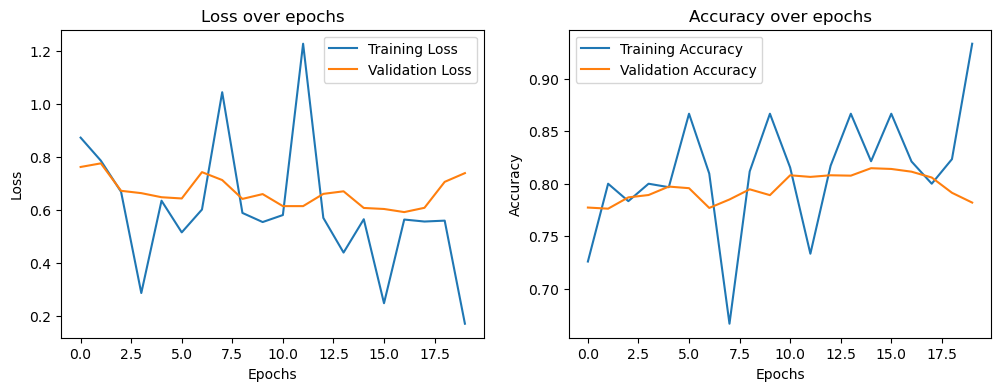

In [95]:
# Acceder a los datos de pérdida y precisión
loss = history_fine_tune.history['loss']
val_loss = history_fine_tune.history['val_loss']
accuracy = history_fine_tune.history['accuracy']
val_accuracy = history_fine_tune.history['val_accuracy']

# Graficar la pérdida del modelo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['loss'], label='Training Loss')
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Graficar la precisión del modelo
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['accuracy'], label='Training Accuracy')
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [96]:
epochs = list(range(1, 21))
data = {
    'Epoch': epochs,
    'Trainning Loss': loss,
    'Validation Loss': val_loss,
    'Training Accuracy': accuracy,
    'Validation  Accuracy': val_accuracy
}
df = pd.DataFrame(data)

# Imprimir la tabla
print(df)

    Epoch  Trainning Loss  Validation Loss  Training Accuracy  \
0       1        0.872874         0.762390           0.725890   
1       2        0.786222         0.775988           0.800000   
2       3        0.668960         0.672626           0.783411   
3       4        0.287728         0.663855           0.800000   
4       5        0.635354         0.648465           0.796699   
5       6        0.516077         0.643787           0.866667   
6       7        0.602174         0.742914           0.809662   
7       8        1.043779         0.713176           0.666667   
8       9        0.589339         0.642159           0.811699   
9      10        0.555001         0.660267           0.866667   
10     11        0.581376         0.614981           0.815420   
11     12        1.226480         0.614960           0.733333   
12     13        0.570669         0.661108           0.817103   
13     14        0.440109         0.670757           0.866667   
14     15        0.565622

In [97]:
# Accuracy final en entrenamiento
val_loss = history_fine_tune.history['val_loss'][-1]

In [98]:
print('Perdida final en Train:', history_fine_tune.history['loss'][-1])
print("Pérdida final en Validation:", history_fine_tune.history['val_loss'][-1])


print("Accuracy final en Train:", history_fine_tune.history['accuracy'][-1])
print("Accuracy final en Validation:", history_fine_tune.history['val_accuracy'][-1])

Perdida final en Train: 0.17215093970298767
Pérdida final en Validation: 0.7392613887786865
Accuracy final en Train: 0.9333333373069763
Accuracy final en Validation: 0.7820330858230591


In [99]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}
print(index_to_class)
with open("index_to_class_modelo14.json", "w") as f:
    json.dump(index_to_class, f, indent=4, ensure_ascii=False)

{0: 'Yuca_Enferma_Pudrición de la yuca', 1: 'Yuca_Enferma_Manchas amarillas en la yuca', 2: 'Yuca_Enferma_Venas marrones de la yuca', 3: 'Yuca_Enferma_Manchas verdes en la yuca', 4: 'Yuca_Saludable_Saludable', 5: 'Fresa_Saludable_Saludable', 6: 'Papa_Enferma_Quemado de la papa', 7: 'Maíz_Saludable_Saludable', 8: 'Tomate_Enferma_Pinta en ojo de buey', 9: 'Papa_Enferma_Pudrición de la papa', 10: 'Tomate_Enferma_Pudrición de la papa', 11: 'Tomate_Enferma_Moteado del tomate', 12: 'Tomate_Enferma_Hongo blanco del tomate', 13: 'Manzana_Enferma_Hongo del manzano', 14: 'Tomate_Enferma_Puntos negros del tomate', 15: 'Tomate_Enferma_Quemado de la papa', 16: 'Maíz_Enferma_Moho rojo del maíz', 17: 'Tomate_Saludable_Saludable', 18: 'Tomate_Enferma_Hojas enrolladas del tomate', 19: 'Manzana_Enferma_Costra de la manzana', 20: 'Maíz_Enferma_Quemazón del maíz', 21: 'Tomate_Enferma_Polvillo rojo', 22: 'Tomate_Enferma_Puntitos marrones en las hojas', 23: 'Maíz_Enferma_Pinta gris', 24: 'Manzana_Enferma_Pu

## 15. Testeo del Modelo

In [101]:
test.Planta = test.Planta.astype('str')

test_generator =  datagen.flow_from_dataframe(test,
                         directory = "Datos Finales",
                         subset = "training",
                         x_col = "image_id",
                         y_col = "Planta_Condición_Enfermedad",
                         target_size = (image_height,image_width),
                         batch_size = batch_size,
                         class_mode = "categorical")

Found 8471 validated image filenames belonging to 37 classes.


In [102]:
# -------------------------
# 1. Obtener predicciones completas para test
# -------------------------
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

565/565 ━━━━━━━━━━━━━━━━━━━━ 147s 259ms/step


<Figure size 20000x8000 with 0 Axes>

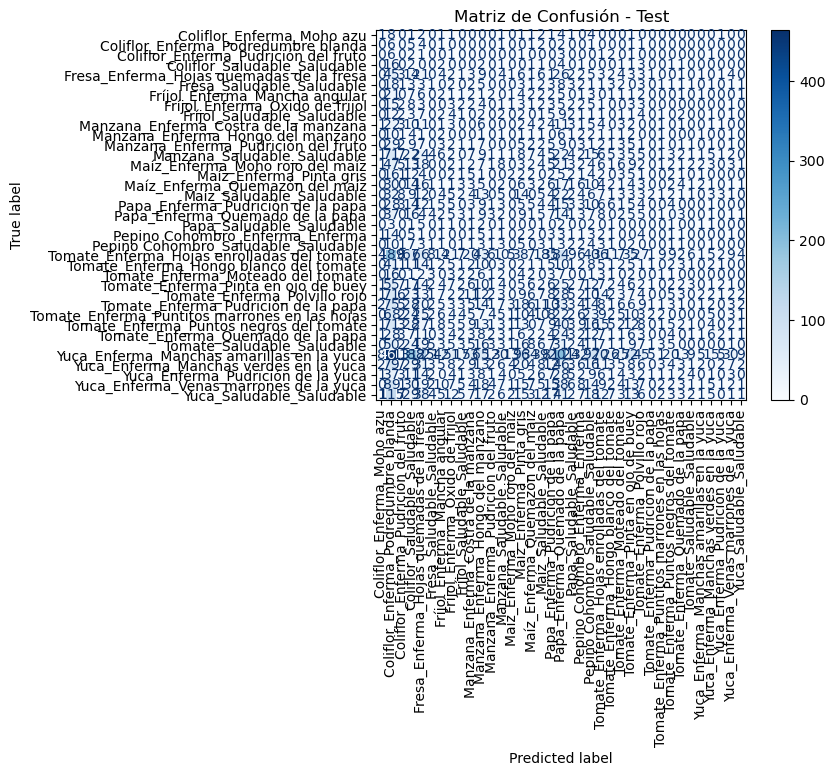

In [103]:
# -------------------------
# 2. Matriz de Confusión
# -------------------------
plt.figure(figsize=(200, 80))
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_generator.class_indices.keys())
disp.plot(cmap="Blues", xticks_rotation=90)
plt.title("Matriz de Confusión - Test")
plt.savefig("matriz_confusion_test_modelo_11.png", dpi=300, bbox_inches='tight')
plt.show()

In [104]:
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.0159


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 770ms/step


ValueError: num must be an integer with 1 <= num <= 12, not 13

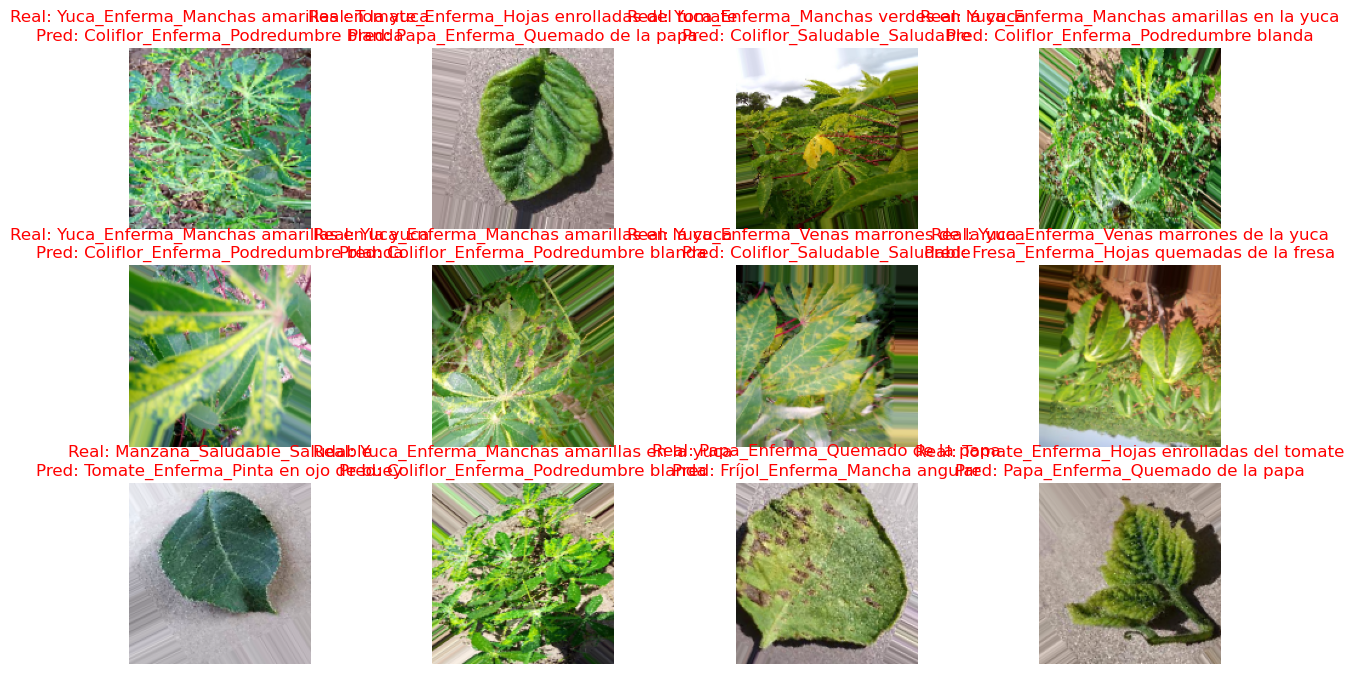

In [105]:
# Función para normalizar imágenes solo para visualización
def normalize_for_display(img):
    img_min = img.min()
    img_max = img.max()
    if img_max > 1.0 or img_min < 0.0:
        img = (img - img_min) / (img_max - img_min + 1e-7)
    return img

# Obtener nombres de clases
class_indices = test_generator.class_indices
class_names = list(class_indices.keys())

# Reiniciar el generador para empezar desde el principio
test_generator.reset()
x_batch, y_true_batch = next(test_generator)

# Obtener predicciones del modelo
y_pred_probs_batch = model.predict(x_batch)
y_pred_batch = np.argmax(y_pred_probs_batch, axis=1)
y_true_batch = np.argmax(y_true_batch, axis=1)

# Número de imágenes a mostrar (máximo el tamaño del batch)
num_samples = x_batch.shape[0]

# Mostrar imágenes con etiquetas
plt.figure(figsize=(15, 8))
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)
    img_to_show = normalize_for_display(x_batch[i])
    plt.imshow(img_to_show)
    plt.axis('off')
    plt.title(
        f"Real: {class_names[y_true_batch[i]]}\nPred: {class_names[y_pred_batch[i]]}",
        color='green' if y_true_batch[i] == y_pred_batch[i] else 'red'
    )
plt.tight_layout()
plt.suptitle("Muestreo de Predicciones vs. Etiquetas Reales", fontsize=16, y=1.02)
plt.show()

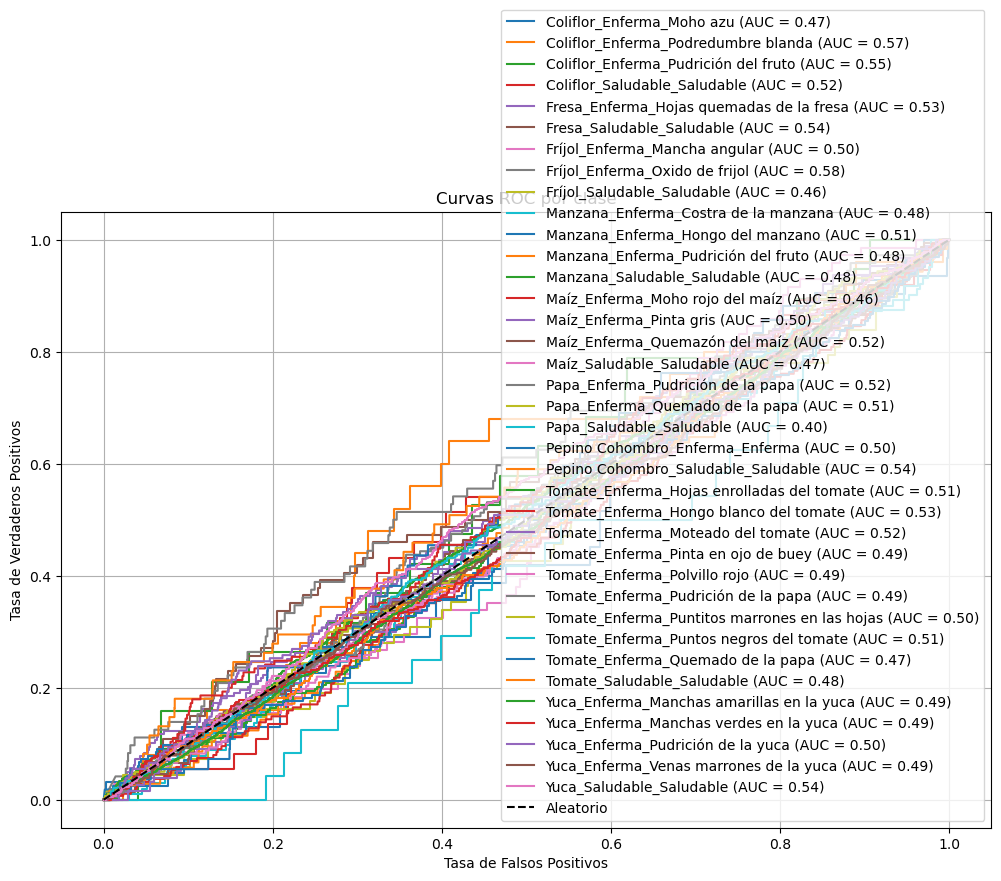

In [106]:
# 3. Convertir etiquetas reales a one-hot
n_classes = y_pred_probs.shape[1]
y_true_onehot = to_categorical(y_true, num_classes=n_classes)

# 4. Calcular ROC y AUC por clase
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 5. Obtener nombres de clase
class_names = list(test_generator.class_indices.keys())

# 6. Graficar curvas ROC
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC por clase')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [108]:
from sklearn.metrics import roc_auc_score

# AUC macro (promedio de clases, todas igual de importantes)
auc_macro = roc_auc_score(y_true_onehot, y_pred_probs, average='macro')

# AUC micro (promedia sobre todas las instancias)
auc_micro = roc_auc_score(y_true_onehot, y_pred_probs, average='micro')

print(f"AUC Macro promedio: {auc_macro:.4f}")
print(f"AUC Micro promedio: {auc_micro:.4f}")


AUC Macro promedio: 0.5021
AUC Micro promedio: 0.4932


In [110]:
# Asegúrate de tener esto:
# y_pred = np.argmax(y_pred_probs, axis=1)
# y_true = test_generator.classes

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# F1 Scores
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_micro = f1_score(y_true, y_pred, average='micro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print(f"F1 Score (micro): {f1_micro:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")

# Detalle por clase
class_names = list(test_generator.class_indices.keys())
print("\nReporte de clasificación por clase:")
print(classification_report(y_true, y_pred, target_names=class_names))


Accuracy: 0.0159
F1 Score (macro): 0.0131
F1 Score (micro): 0.0159
F1 Score (weighted): 0.0153

Reporte de clasificación por clase:
                                               precision    recall  f1-score   support

                    Coliflor_Enferma_Moho azu       0.04      0.03      0.03        31
          Coliflor_Enferma_Podredumbre blanda       0.00      0.24      0.01        25
         Coliflor_Enferma_Pudrición del fruto       0.00      0.00      0.00        19
                 Coliflor_Saludable_Saludable       0.00      0.05      0.01        37
     Fresa_Enferma_Hojas quemadas de la fresa       0.03      0.12      0.05       179
                    Fresa_Saludable_Saludable       0.01      0.01      0.01        74
                Fríjol_Enferma_Mancha angular       0.01      0.03      0.02        71
               Fríjol_Enferma_Oxido de frijol       0.02      0.04      0.02        72
                   Fríjol_Saludable_Saludable       0.01      0.01      0.01        

## 16. Guardar el modelo entrenado

In [113]:
model.save('modelo_14_resnet50_fine_tuned_class_weighted.h5')

In [115]:
class_indices = train_generator.class_indices  # o test_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}